# Projet Apprentisage Statistique - COVID 19

# Plan

1. Problem and goal of our studies
2. Data description and brief analysis (Missing Values and EDA)
3. Data preparation (Cleaning and Feature Engineering)
4. Definition and estimation of the Explicative Model and evaluation of Quality\
   Verification of the model. 
5. Interpretation, conclusion and Follow ups. 

# 1. Présentation du problèmen et des objectifs de l'étude. 
- **Problem :** A year ago, when WHO declared COVID-19 outbreak a pandemic,\
countries in WHO South-East Asia Region were either responding to their first\
cases of importation or cluster of cases or keeping a strict vigil against\
mportation of the new coronavirus. The following months were unprecedented,\
and for many reasons. Scientists, experts, governments, societies, communities\
and even individuals responded to the new virus with urgency and measures\
never witnessed before. 
- **Goal :** Fellow Data Scientist and ML engineers, can you identify which\
countries are doing relatively well and which ones need immediate attention? 

## **Ideas**

We can do a basic regression model as a Base Model. Then, we can do a PCA to see\
which variables may better explain our date.\
Afterwards, we will apply more complex techniques and at the end we will evaluate\
which one is the best.\
We can also evaluate the possibility to create a score minimizing deaths and cases.

# 2. Import, description and EDA

## 2.1. Import

In [266]:
# Package Importation
import os
import pandas as pd
import numpy as np 
import skimpy as skim
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor

import sklearn.preprocessing as pre
import sklearn.cluster as clu
import sklearn.metrics as met
import sklearn.mixture as mix
import plotly.express as px


from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA

In [267]:
import warnings 
warnings.filterwarnings("ignore")

In [268]:
# Data Importation 
df = pd.read_csv("../data/CovidCases.csv", delimiter =',')

## 2.2. Description

In [269]:
df.head()

,ID,Country,TotalCases,TotalDeaths,TotalRecovered,ActiveCases,TotalCasesPerMillion,TotalDeathsPerMillion,TotalTests,TotalTestsPerMillion,TotalPopulation
0,1,Yemen,9369,1778.0,5921,1670,306,58.0,265253.0,8651.0,30660443
1,2,Vietnam,839662,20555.0,782199,36908,8529,209.0,42517091.0,431850.0,98453377
2,3,Uzbekistan,178637,1271.0,174213,3153,5241,37.0,1377915.0,40425.0,34086135
3,4,UAE,737890,2114.0,731295,4481,73477,211.0,87246490.0,8687776.0,10042442
4,5,Turkey,7444552,66180.0,6893476,484896,87077,774.0,89847975.0,1050928.0,85493959


In [270]:
df.describe()

,ID,TotalCases,TotalDeaths,TotalRecovered,ActiveCases,TotalCasesPerMillion,TotalDeathsPerMillion,TotalTests,TotalTestsPerMillion,TotalPopulation
count,49.00000,4.900000e+01,48.000000,4.900000e+01,49.000000,49.000000,48.000000,4.800000e+01,4.800000e+01,4.900000e+01
mean,25.00000,1.574671e+06,23732.937500,1.510029e+06,41393.000000,43871.632653,455.375000,2.952919e+07,1.173289e+06,9.495127e+07
std,14.28869,4.943437e+06,68852.400621,4.829174e+06,89902.688282,46256.329145,489.395399,8.651915e+07,1.864261e+06,2.818387e+08
min,1.00000,7.700000e+01,3.000000,6.400000e+01,0.000000,67.000000,3.000000,4.951000e+03,5.741000e+03,4.428110e+05
25%,13.00000,1.150680e+05,1360.250000,9.107400e+04,1670.000000,6484.000000,128.500000,2.334699e+06,1.409660e+05,5.252032e+06
50%,25.00000,4.120790e+05,5105.500000,3.913590e+05,14787.000000,24313.000000,326.500000,7.978141e+06,4.247715e+05,1.701328e+07
75%,37.00000,9.056410e+05,17798.500000,8.474560e+05,29242.000000,78714.000000,626.750000,2.510008e+07,1.031733e+06,5.132540e+07
max,49.00000,3.397161e+07,450814.000000,3.329348e+07,484896.000000,159718.000000,2329.000000,5.836315e+08,8.687776e+06,1.439324e+09


In [271]:
df.shape

(49, 11)

In [272]:
df.dtypes

ID                         int64
Country                   object
TotalCases                 int64
TotalDeaths              float64
TotalRecovered             int64
ActiveCases                int64
TotalCasesPerMillion       int64
TotalDeathsPerMillion    float64
TotalTests               float64
TotalTestsPerMillion     float64
TotalPopulation            int64
dtype: object

In [273]:
skim.skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 49     │ │ int64       │ 6     │                                                          │
│ │ Number of columns │ 11     │ │ float64     │ 4     │                                                          │
│ └───────────────────┴────────┘ │ string      │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━┳━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column   ┃ NA ┃ NA %     ┃ mean     ┃ sd       ┃ p0     ┃ p25     ┃ p50      ┃ p75      ┃ p100    ┃ hist   ┃  │
│ ┡━━━━━━━━━━╇━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩  │
│ │ ID       │  0 │        0 │       25 │    14.29 │      1 │      13 │       25 │       37 │      49 │ ▇▇▇▇▇█ │  │
│ │ TotalCas │  0 │        0 │  1575000 │  4943000 │     77 │  115100 │   412100 │   905600 │ 3397000 │   █    │  │
│ │ es       │    │          │          │          │        │         │          │          │       0 │        │  │
│ │ TotalDea │  1 │ 2.040816 │    23730 │    68850 │      3 │    1360 │     5106 │    17800 │  450800 │   █    │  │
│ │ ths      │    │ 32653061 │          │          │        │         │          │          │         │        │  │
│ │          │    │       23 │          │          │        │         │          │          │         │        │  │
│ │ TotalRec │  0 │        0 │  1510000 │  4829000 │     64 │   91070 │   391400 │   847500 │ 3329000 │   █    │  │
│ │ overed   │    │          │          │          │        │         │          │          │       0 │        │  │
│ │ ActiveCa │  0 │        0 │    41390 │    89900 │      0 │    1670 │    14790 │    29240 │  484900 │   █▁   │  │
│ │ ses      │    │          │          │          │        │         │          │          │         │        │  │
│ │ TotalCas │  0 │        0 │    43870 │    46260 │     67 │    6484 │    24310 │    78710 │  159700 │ █▁▁▂ ▁ │  │
│ │ esPerMil │    │          │          │          │        │         │          │          │         │        │  │
│ │ lion     │    │          │          │          │        │         │          │          │         │        │  │
│ │ TotalDea │  1 │ 2.040816 │    455.4 │    489.4 │      3 │   128.5 │    326.5 │    626.8 │    2329 │  █▄▁▁  │  │
│ │ thsPerMi │    │ 32653061 │          │          │        │         │          │          │         │        │  │
│ │ llion    │    │       23 │          │          │        │         │          │          │         │        │  │
│ │ TotalTes │  1 │ 2.040816 │ 29530000 │ 86520000 │   4951 │ 2335000 │  7978000 │ 25100000 │ 5836000 │   █    │  │
│ │ ts       │    │ 32653061 │          │          │        │         │          │          │      00 │        │  │
│ │          │    │       23 │          │          │        │         │          │          │         │        │  │
│ │ TotalTes │  1 │ 2.040816 │  1173000 │  1864000 │   5741 │  141000 │   424800 │  1032000 │ 8688000 │  █▁▁   │  │
│ │ tsPerMil │    │ 32653061 │          │          │        │         │          │          │         │        │  │
│ │ lion     │    │       23 │          │          │    

## 2.3. EDA

In [274]:
df_quant_var = df.select_dtypes(exclude = 'object').columns
df_qual_var  = df.select_dtypes(include = 'object').columns

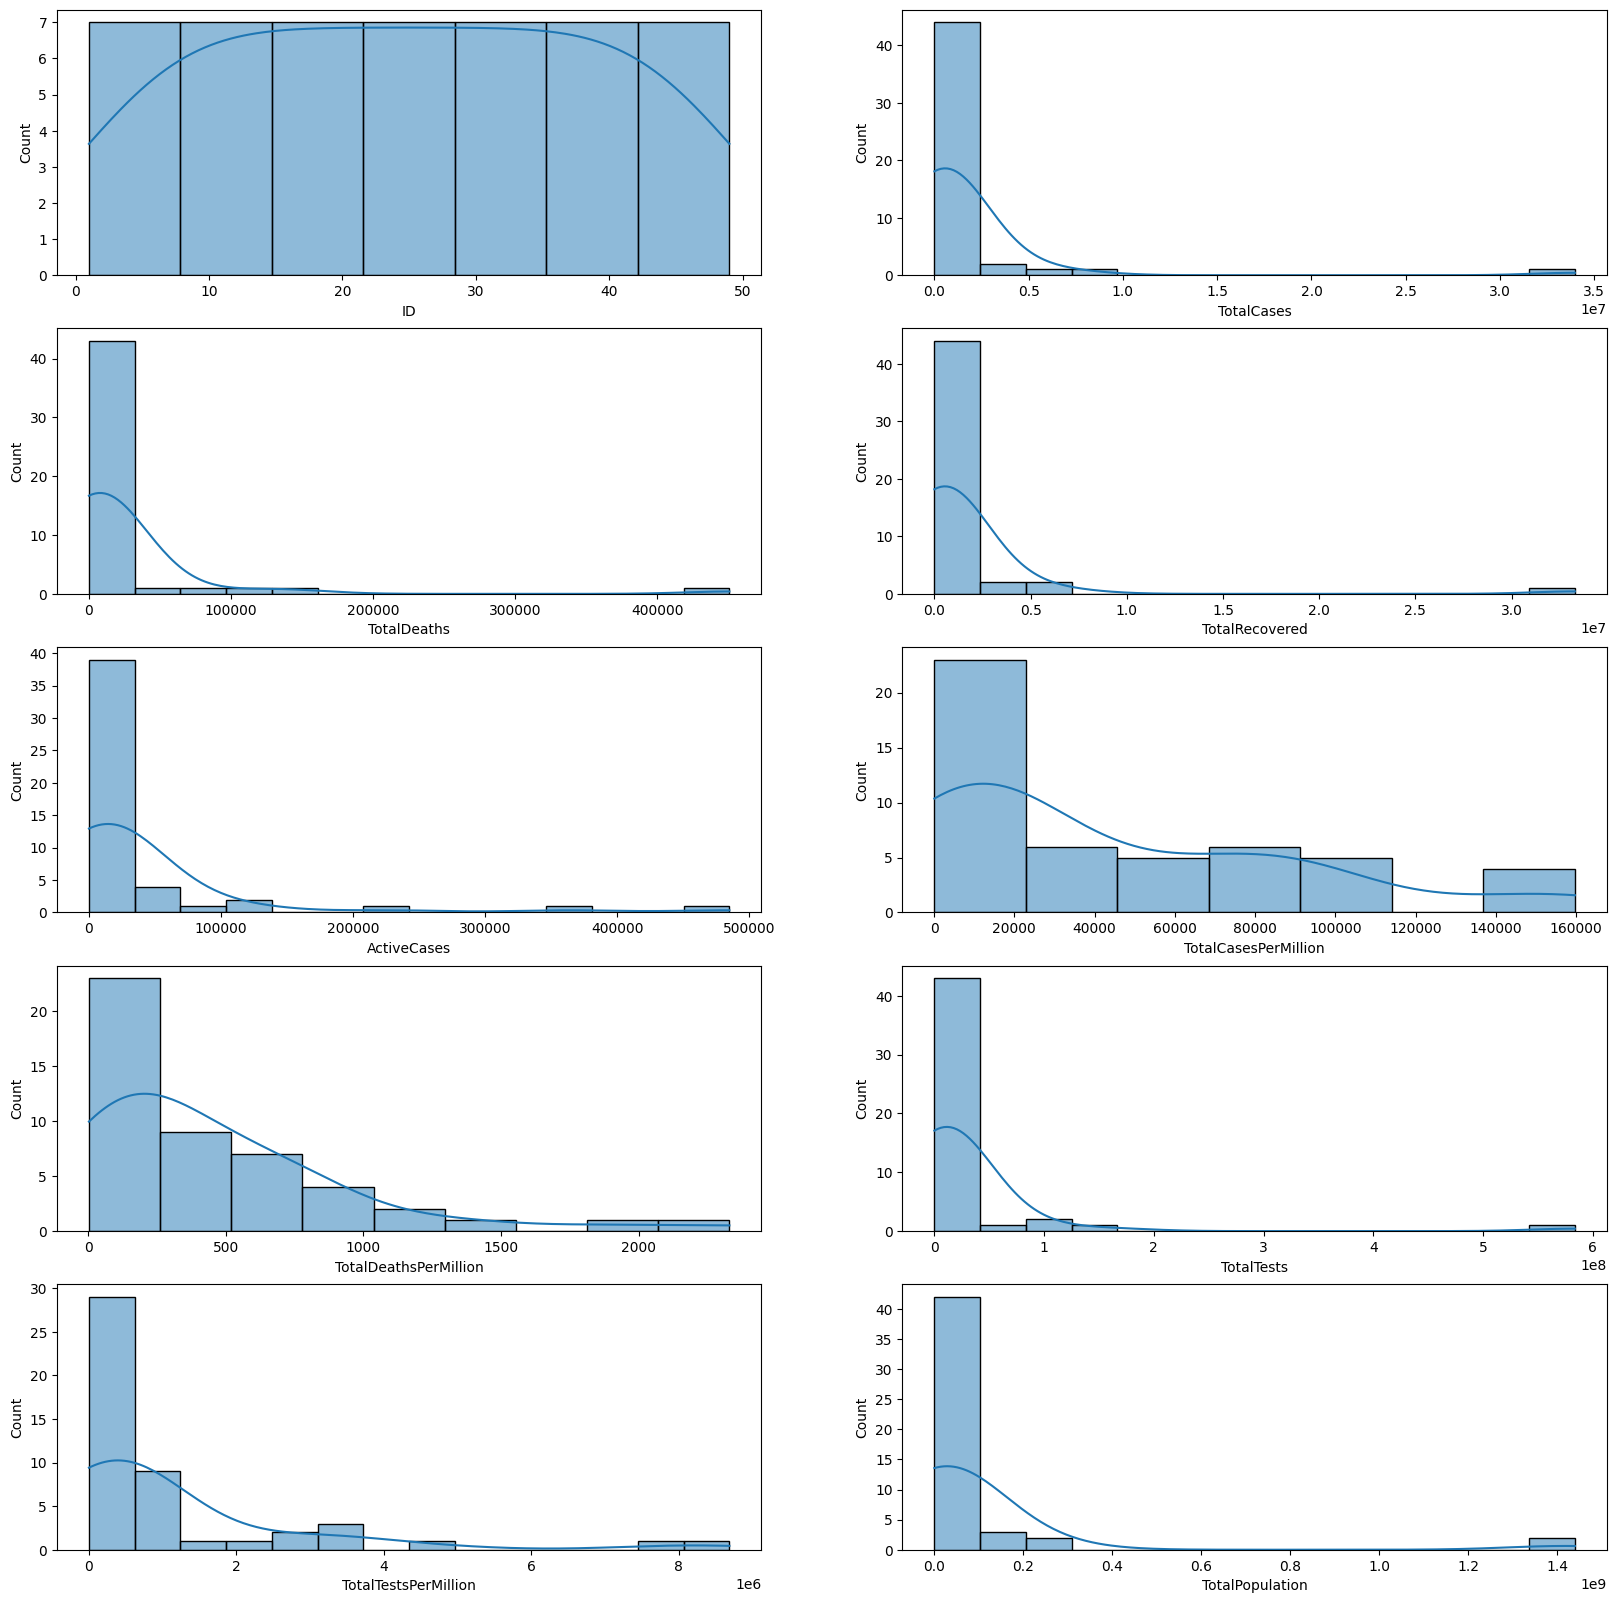

In [275]:
# Univariate analysis Functions 

fig, ax = plt.subplots(5,2, figsize = (20,20))
for i, subplots in zip(df_quant_var, ax.flatten()) :
    sns.histplot(df[i], ax = subplots ,palette= 'pastel', kde = True)
fig.show()


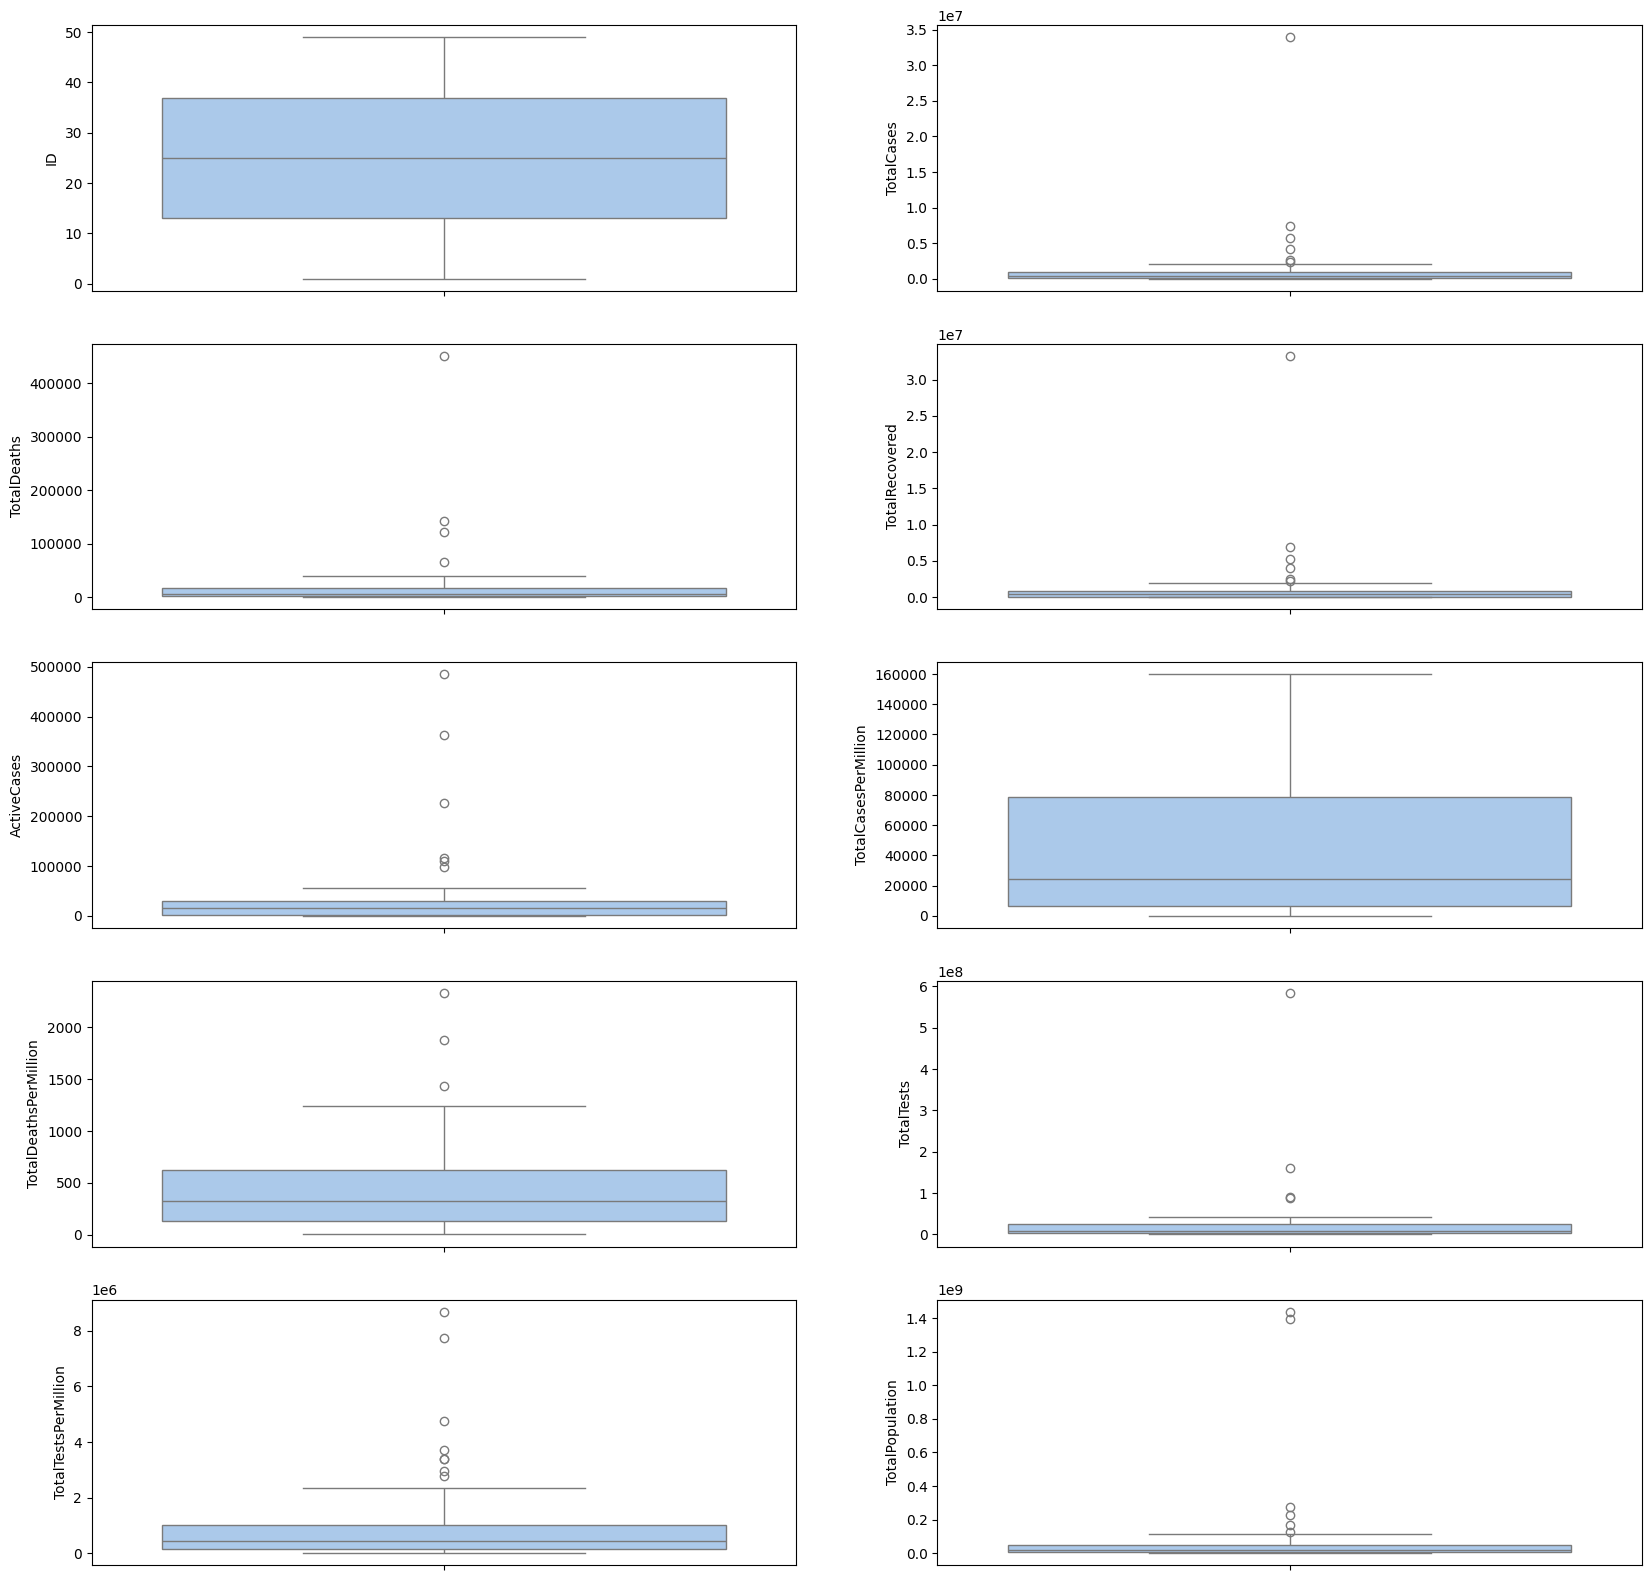

In [276]:
# Univariate analysis Functions 

fig, ax = plt.subplots(5,2, figsize = (20,20))
for i, subplots in zip(df_quant_var, ax.flatten()) :
    sns.boxplot(df[i], ax = subplots ,palette= 'pastel')
fig.show()


- Notes : Most of the variables seem to have a similar distribution. Variables\
constructions method make us think that there may be multicolinearity. For\
example we have all those variables 'per million'. In the same way, we may have\
multicolinearity between the number of tests and the number of overall cases. 

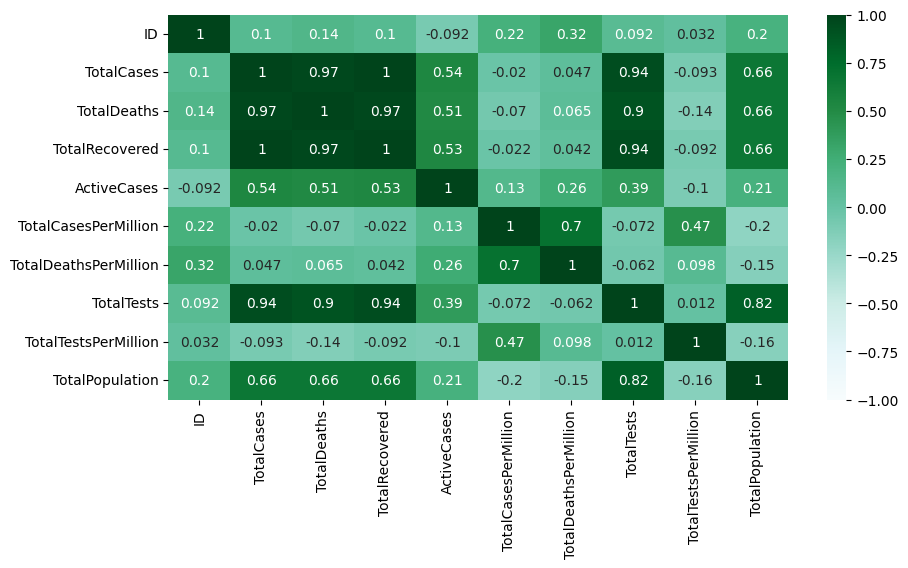

In [277]:
plt.figure(figsize=(10,5))
sns.heatmap(df[df_quant_var].corr(method ='pearson'),vmax =1,vmin=-1, annot=True, cmap = "BuGn")
plt.show()

Notes : Correlation Matrix shows us that there may be some highly correlated\
    variables. Indeed, some variables contain a score of 1. For example between\
    the variables total cases and total  test where we have a correlation of 0.94. 

# 3. Data preparation (Cleaning and Feature Engineering)

In [278]:
# We create to DataFrames in order to test a DataFrame without created KPIs and 
# the one that contains this information. 

df_base = df.copy()
df_aug = df.copy()

In [279]:
df_aug['CaseFatalityRatio'] = df_aug['TotalDeathsPerMillion']/df_aug['TotalCasesPerMillion']
df_aug['TestPositivityTate'] = df_aug['TotalCasesPerMillion']/df_aug['TotalTestsPerMillion']
df_aug["ActiveCasesPerMillion"] =  (df_aug["ActiveCases"]/df_aug['TotalPopulation'])*1000000

In [280]:
df_aug_quant_var = df_aug.select_dtypes(exclude= 'object').columns

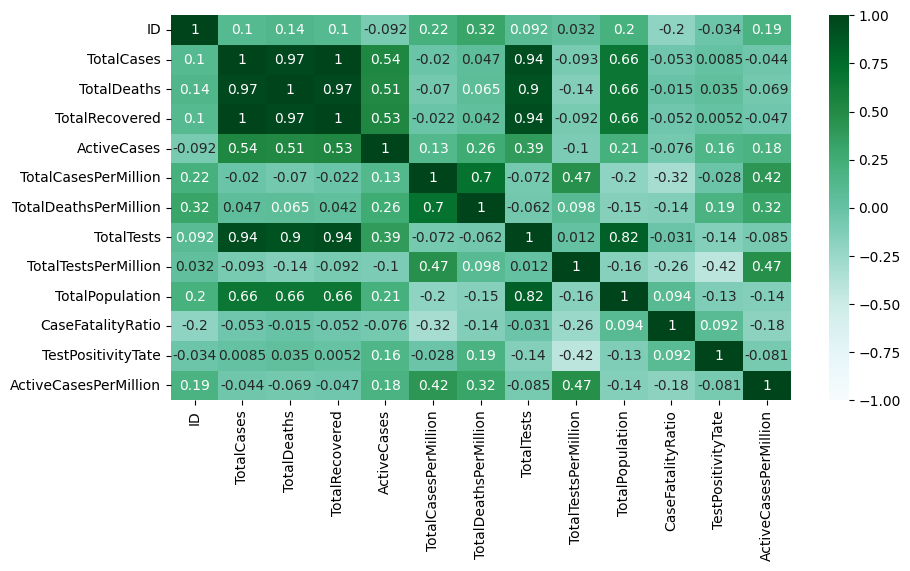

In [281]:
plt.figure(figsize=(10,5))
sns.heatmap(df_aug[df_aug_quant_var].corr(method ='pearson'),vmax =1,vmin=-1, annot=True, cmap = "BuGn")
plt.show()

In [282]:
df_aug_clean = df_aug.drop(columns = ['TotalCases','TotalDeaths','TotalRecovered','TotalTests','TotalPopulation','ID'])
df_base_clean = df_base.drop(columns = ['TotalCases','TotalDeaths','TotalRecovered','TotalTests','TotalPopulation','ID'])

In [283]:
# Missing Values
df_aug_clean[(df_aug_clean['TotalTestsPerMillion'].isna())|(df_aug_clean['TotalDeathsPerMillion'].isna())]

,Country,ActiveCases,TotalCasesPerMillion,TotalDeathsPerMillion,TotalTestsPerMillion,CaseFatalityRatio,TestPositivityTate,ActiveCasesPerMillion
7,Tajikistan,0,1742,13.0,NaN,0.007463,NaN,0.000000
24,Macao,13,117,NaN,7495.0,NaN,0.01561,19.679229


In [284]:
df_aug_clean_index = df_aug_clean.set_index('Country')

df_aug_columns = df_aug_clean_index.columns
df_aug_index = df_aug_clean_index.index

In [285]:
df_base_clean_index = df_base_clean.set_index('Country')

df_base_columns = df_base_clean_index.columns
df_base_index = df_base_clean_index.index

In [286]:
scaler = pre.StandardScaler()
df_aug_clean_scaler = pd.DataFrame(scaler.fit_transform(df_aug_clean_index),
                                   columns=df_aug_columns,
                                   index = df_aug_index)

In [287]:
scaler = pre.StandardScaler()
df_base_clean_scaler = pd.DataFrame(scaler.fit_transform(df_base_clean_index),
                                   columns=df_base_columns,
                                   index = df_base_index)

In [288]:
# Missing Values imputation
imputer = KNNImputer(n_neighbors= 4, weights='distance')
df_aug_clean_imputed = pd.DataFrame(imputer.fit_transform(df_aug_clean_scaler),
                                    columns = df_aug_columns,
                                    index = df_aug_index)


In [289]:
# Missing Values imputation
imputer = KNNImputer(n_neighbors= 4, weights='distance')
df_base_clean_imputed = pd.DataFrame(imputer.fit_transform(df_base_clean_scaler),
                                    columns = df_base_columns,
                                    index = df_base_index)

# 4. Definition and estimation of the Explicative Model and/or predictive model. 

## 4.1. Dimension Reduction - PCA over Base DF

In [290]:
pca = PCA() 
pca.fit(df_base_clean_imputed)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [291]:
n = df_base_clean_imputed.shape[0]
p = df_base_clean_imputed.shape[1]-1
Dimension = ['Dim' +' '+str(x+1) for x in range(len(pca.explained_variance_+1))]
eigval = ((n-1)/n)*pca.explained_variance_

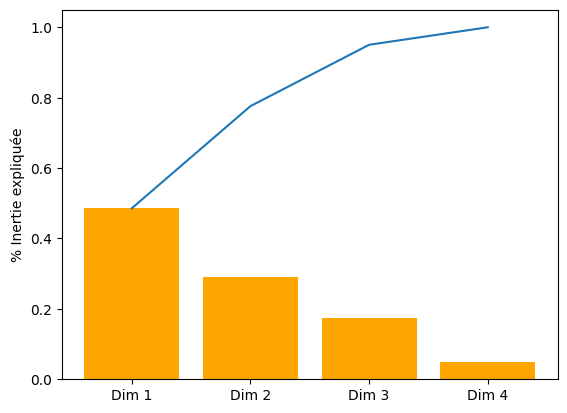

In [292]:
# Variance Expliquée par chaque dimension. 
plt.Figure(figsize=(10,5))
plt.plot(Dimension , np.cumsum(pca.explained_variance_ratio_))
plt.bar(Dimension , pca.explained_variance_ratio_, color = 'Orange')
plt.ylabel('% Inertie expliquée')
plt.show()


In [293]:
# Representation de la PCA. 
pca_df_base = pca.transform(df_base_clean_imputed)
dim_pca_df_base = pd.DataFrame({'Dim 1':pca_df_base[:,0], 
                           'Dim 2':pca_df_base[:,1], 
                           'Dim 3':pca_df_base[:,2],
                           'Country': df['Country']})
dim_pca_df_base.head()

,Dim 1,Dim 2,Dim 3,Country
0,-1.455469,-0.008300,-0.182395,Yemen
1,-0.974203,0.192641,0.047027,Vietnam
2,-1.399646,-0.031106,-0.156528,Uzbekistan
3,1.526825,-3.038312,2.335480,UAE
4,2.124102,3.740143,2.726371,Turkey


In [294]:
# Cercle de correlation. 
n = df_base_clean_imputed.shape[0]
p = df_base_clean_imputed.shape[1]
eigval = ((n-1)/n)* pca.explained_variance_ 
sqrt_eigval = np.sqrt(eigval) 
corvar = np.zeros((p,p)) 

for i in range(p):
    corvar[:,i] = pca.components_[i,:] * sqrt_eigval[i]
coordvar = pd.DataFrame({'Variable': df_base_clean_imputed.columns, 'Correlation 1': corvar[:,0], 'Correlation 2': corvar[:,1],'Correlation 3': corvar[:,3]})
coordvar

,Variable,Correlation 1,Correlation 2,Correlation 3
0,ActiveCases,0.308458,0.786724,0.019683
1,TotalCasesPerMillion,0.930843,-0.136248,0.319481
2,TotalDeathsPerMillion,0.844580,0.263061,-0.270424
3,TotalTestsPerMillion,0.505791,-0.668304,-0.148408


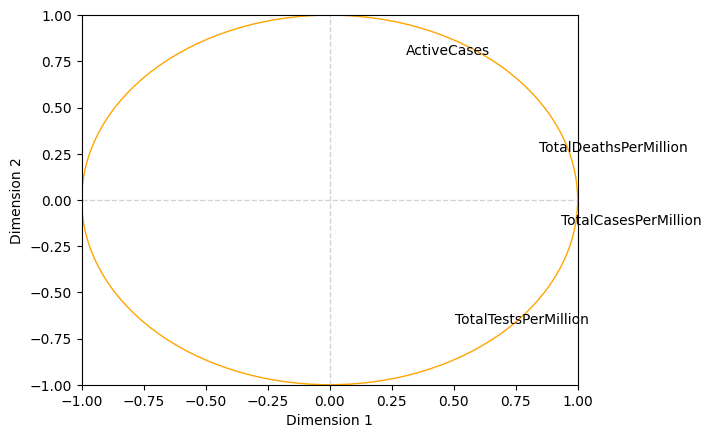

In [295]:
fig, ax = plt.subplots()
ax.set_ylim(-1,1)
ax.set_xlim(-1,1)
ax.axvline(x = 0, color = 'lightgray', linestyle = 'dashed', linewidth = 1)
ax.axhline(y = 0, color = 'lightgray', linestyle = 'dashed', linewidth = 1)
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
for j in range(p): 
    ax.text(coordvar['Correlation 1'][j],coordvar['Correlation 2'][j],coordvar['Variable'][j])
plt.gca().add_artist(plt.Circle((0,0),1,color='orange',fill=False))
plt.show()

# Le premier axe semble avoir un effet taille et c'est le premier axe qui concentre la plus part d'info. 
# Une lecture pertinente peut être : À droite les pays ayant des scores éléves  et à gauche le contraire. 
# L'axe Y, je la lirais comme Beaucoup de morts en haut et peu de morts en bas. 
# Les pays proches du 0 sont écrasés à mon avis. 


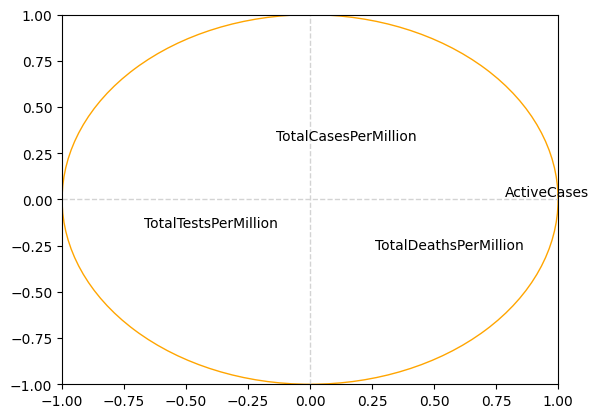

In [296]:
fig, ax = plt.subplots()
ax.set_ylim(-1,1)
ax.set_xlim(-1,1)
ax.axvline(x = 0, color = 'lightgray', linestyle = 'dashed', linewidth = 1)
ax.axhline(y = 0, color = 'lightgray', linestyle = 'dashed', linewidth = 1)
for j in range(p): 
    ax.text(coordvar['Correlation 2'][j],coordvar['Correlation 3'][j],coordvar['Variable'][j])
plt.gca().add_artist(plt.Circle((0,0),1,color='orange',fill=False))
plt.show()

# X comme le fait d'avoir beaucoup de morts et Y comme le fait d'avoir une actualité 
# forte en termes de cas. 

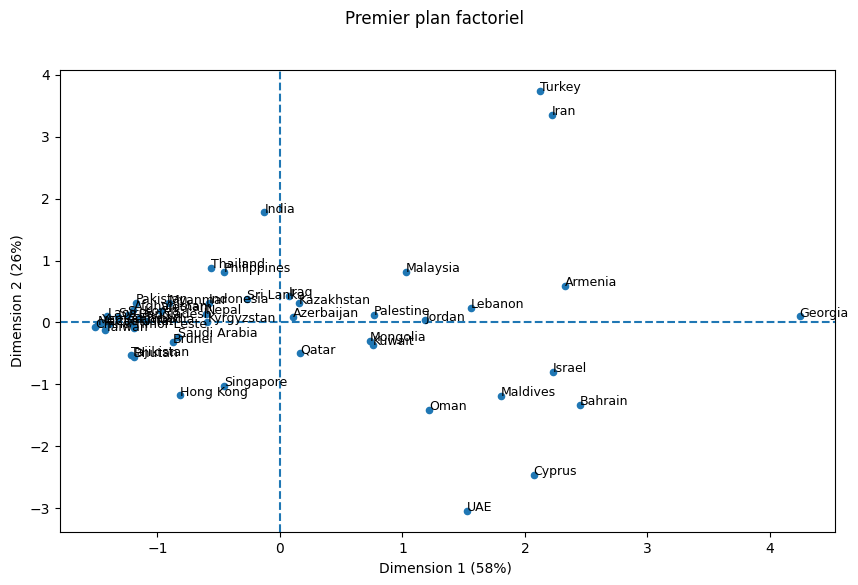

In [297]:
# Graphique ACP annoté des Pays. Dimensions 1 et 2.
fig, ax = plt.subplots()
fig.set_figheight(6)
fig.set_figwidth(10)
dim_pca_df_base.plot.scatter("Dim 1", "Dim 2", ax = ax ) 
for i in dim_pca_df_base.iterrows():
    ax.annotate(i[1]["Country"], (i[1]['Dim 1'], i[1]['Dim 2']), fontsize = 9)
plt.xlabel("Dimension 1 (58%) ") 
plt.ylabel("Dimension 2 (26%)")
plt.axhline(y =0, linestyle = 'dashed')
plt.axvline(x=0, linestyle ='dashed')

plt.suptitle("Premier plan factoriel")
plt.show()

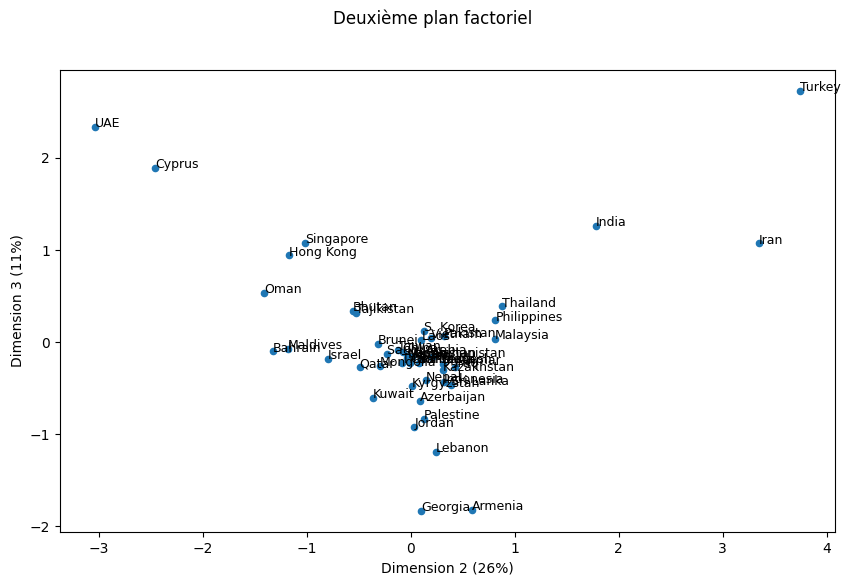

In [298]:
# Graphique ACP annoté des Pays. Dimensions 2 et 3.
fig, ax = plt.subplots()
fig.set_figheight(6)
fig.set_figwidth(10)
dim_pca_df_base.plot.scatter("Dim 2", "Dim 3", ax = ax) 
for i in dim_pca_df_base.iterrows():
    ax.annotate(i[1]["Country"], (i[1]['Dim 2'], i[1]['Dim 3']), fontsize = 9)
plt.xlabel("Dimension 2 (26%)") 
plt.ylabel("Dimension 3 (11%)")
plt.suptitle("Deuxième plan factoriel ")
plt.show()

In [299]:
# Graphique 3D de l'ACP.  Clustering Inclus. 
fig = px.scatter_3d(dim_pca_df_base, x='Dim 1', y='Dim 2', z='Dim 3', text = 'Country')
fig.show()

## 4.1.2 Clustering - KMeans over Base DF

In [300]:
# Données de la PCA à utiliser dans Kmeans.
dim_pca_df_base_km = dim_pca_df_base.iloc[:,:-1]

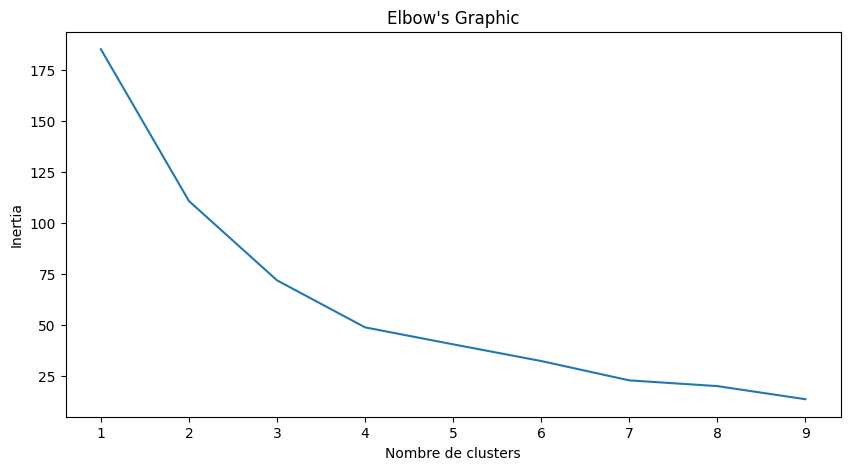

In [301]:
# Implementation de la methode du coude pour la selection optimale de K. 
elbow_scores = []
k = range(1, 10,1)

for i in k: 
    km = clu.KMeans(n_clusters= i)
    km.fit(dim_pca_df_base_km)
    elbow_scores.append(km.inertia_)

plt.figure(figsize=(10,5))
plt.plot(k, elbow_scores)
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertia")
plt.title("Elbow's Graphic")
plt.show()
   

In [302]:
# Focus sur le k optimal. 
km = clu.KMeans(n_clusters= 3)
km.fit(dim_pca_df_base_km)
group = km.predict(dim_pca_df_base_km)
centers = km.cluster_centers_

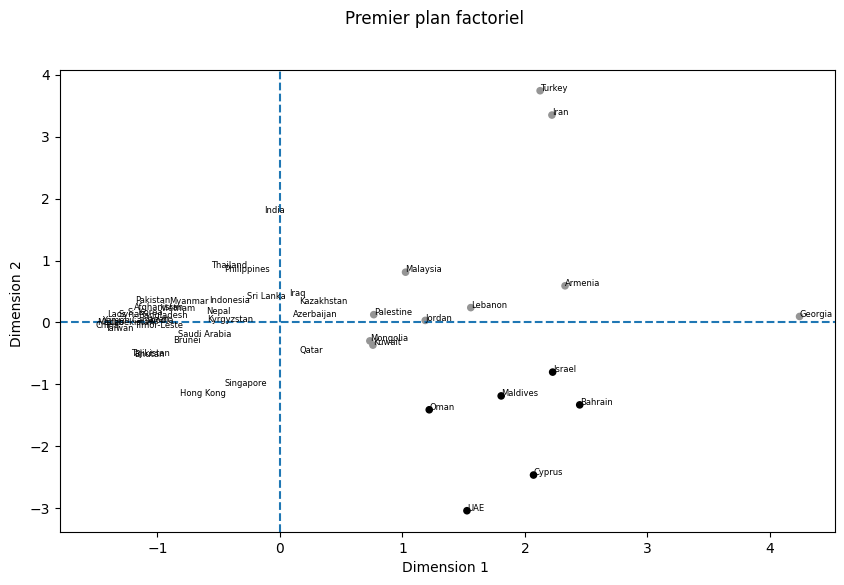

In [303]:
# Graphique ACP annoté des Pays. Dimensions 1 et 2. Clustering Inclus.
fig, ax = plt.subplots()
dim_pca_df_base_km.plot.scatter("Dim 1", "Dim 2", ax = ax, color = group ) 
fig.set_figheight(6)
fig.set_figwidth(10)
for i in dim_pca_df_base.iterrows():
    ax.annotate(i[1]["Country"], (i[1]['Dim 1'], i[1]['Dim 2']), fontsize = 6)
plt.xlabel("Dimension 1 ") 
plt.ylabel("Dimension 2 ")
plt.axhline(y =0, linestyle = 'dashed')
plt.axvline(x=0, linestyle ='dashed')

plt.suptitle("Premier plan factoriel")
plt.show()

In [304]:
# Graphique 3D de l'ACP.  Clustering Inclus. 
fig = px.scatter_3d(dim_pca_df_base, x='Dim 1', y='Dim 2', z='Dim 3', text = 'Country', color = group)
fig.show()

In [305]:
# Silhouette Score pour la qualité du clustering 
s_score = met.silhouette_score(dim_pca_df_base_km , group)
print(f"Le score de silhouette pour la qualité du clustering est : {s_score}")


Le score de silhouette pour la qualité du clustering est : 0.5098604009936897


In [306]:
dim_pca_df_base['Group'] = np.transpose(group)
countryCluster = dim_pca_df_base.drop(columns=['Dim 1', 'Dim 2', 'Dim 3'])

In [307]:
for i in range(3): 
    display(countryCluster[countryCluster['Group']== i ])
    print('----------------')
    

,Country,Group
0,Yemen,0
1,Vietnam,0
2,Uzbekistan,0
5,Timor-Leste,0
6,Thailand,0
7,Tajikistan,0
8,Taiwan,0
9,Syria,0
10,Sri Lanka,0
11,Singapore,0


----------------


,Country,Group
4,Turkey,1
16,Palestine,1
21,Mongolia,1
23,Malaysia,1
25,Lebanon,1
28,Kuwait,1
30,Jordan,1
34,Iran,1
38,Georgia,1
47,Armenia,1


----------------


,Country,Group
3,UAE,2
18,Oman,2
22,Maldives,2
32,Israel,2
39,Cyprus,2
45,Bahrain,2


----------------


## 4.1.3 Clustering - GMM over DF Base

In [308]:
nb_components_base = list(range(2,11,1))
silhouettes_scores_base = []

In [309]:
for n in nb_components_base: 
    gmm = mix.GaussianMixture(n_components= n, random_state= 42)
    gmm.fit(dim_pca_df_base_km)
    group = gmm.predict(dim_pca_df_base_km)
    s_score = met.silhouette_score(dim_pca_df_base_km , group)
    silhouettes_scores_base.append(s_score)
    

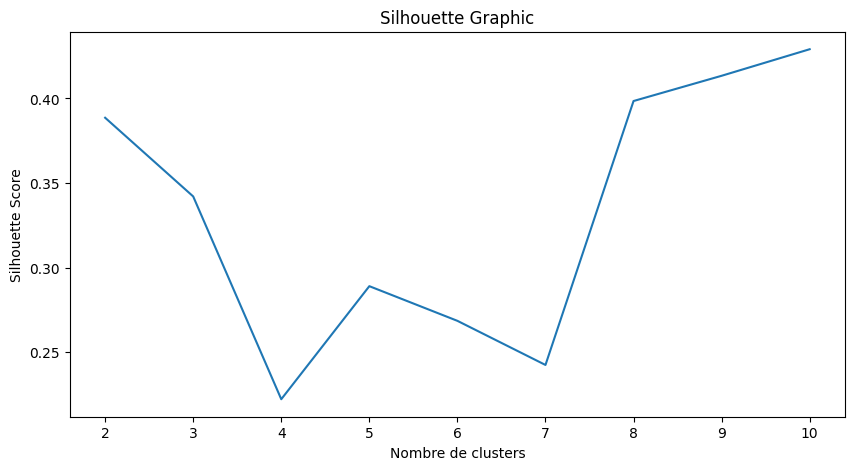

In [310]:
plt.figure(figsize=(10,5))
plt.plot(nb_components_base, silhouettes_scores_base)
plt.xlabel("Nombre de clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Graphic")
plt.show()

In [311]:
gmm = mix.GaussianMixture(n_components= 2, random_state= 42)
gmm.fit(dim_pca_df_base_km)
group = gmm.predict(dim_pca_df_base_km)
s_score = met.silhouette_score(dim_pca_df_base_km , group)

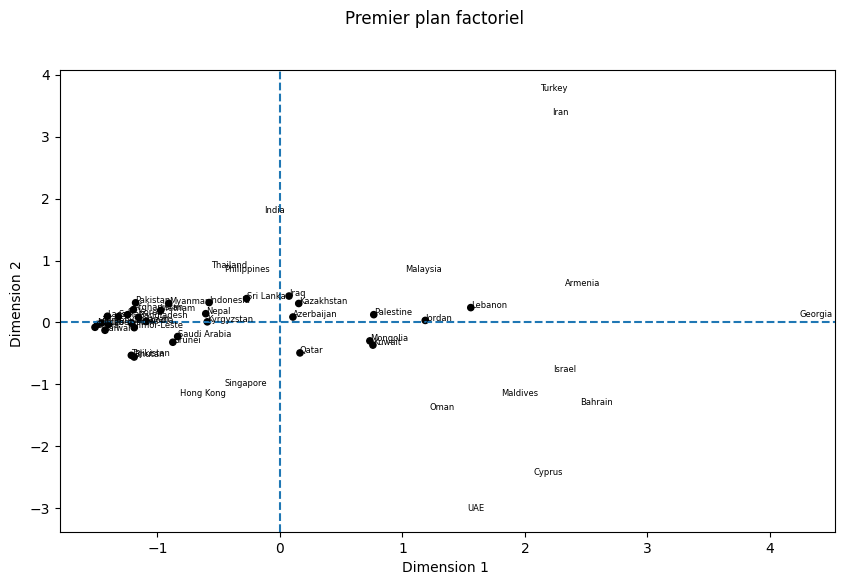

In [312]:
# Graphique ACP annoté des Pays. Dimensions 1 et 2. Clustering Inclus.
fig, ax = plt.subplots()
dim_pca_df_base_km.plot.scatter("Dim 1", "Dim 2", ax = ax, color = group ) 
fig.set_figheight(6)
fig.set_figwidth(10)
for i in dim_pca_df_base.iterrows():
    ax.annotate(i[1]["Country"], (i[1]['Dim 1'], i[1]['Dim 2']), fontsize = 6)
plt.xlabel("Dimension 1 ") 
plt.ylabel("Dimension 2 ")
plt.axhline(y =0, linestyle = 'dashed')
plt.axvline(x=0, linestyle ='dashed')

plt.suptitle("Premier plan factoriel")
plt.show()

In [313]:
# Graphique 3D de l'ACP.  Clustering Inclus. 
fig = px.scatter_3d(dim_pca_df_base, x='Dim 1', y='Dim 2', z='Dim 3', text = 'Country', color = group)
fig.show()

## 4.2.1 Dimension Reduction - PCA over Augmented DF

In [314]:
pca = PCA() 
pca.fit(df_aug_clean_imputed)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [315]:
n = df_aug_clean_imputed.shape[0]
p = df_aug_clean_imputed.shape[1]-1
Dimension = ['Dim' +' '+str(x+1) for x in range(len(pca.explained_variance_+1))]
eigval = ((n-1)/n)*pca.explained_variance_

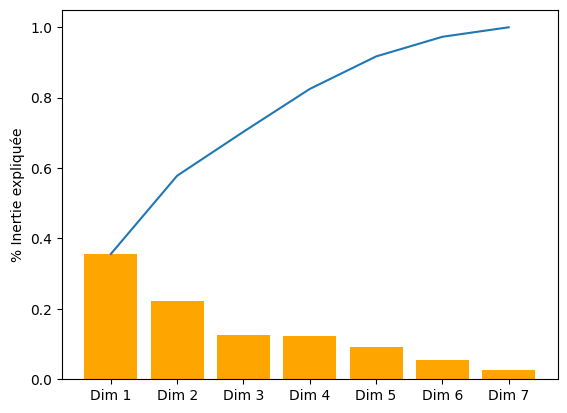

In [316]:
# Variance Expliquée par chaque dimension. 
plt.Figure(figsize=(10,5))
plt.plot(Dimension , np.cumsum(pca.explained_variance_ratio_))
plt.bar(Dimension , pca.explained_variance_ratio_, color = 'Orange')
plt.ylabel('% Inertie expliquée')
plt.show()


In [317]:
# Representation de la PCA. 
pca_df_aug = pca.transform(df_aug_clean_imputed)
dim_pca_df_aug = pd.DataFrame({'Dim 1':pca_df_aug[:,0], 
                           'Dim 2':pca_df_aug[:,1], 
                           'Dim 3':pca_df_aug[:,2],
                           'Country': df['Country']})
dim_pca_df_aug.head()

,Dim 1,Dim 2,Dim 3,Country
0,-3.215068,-0.119546,-2.138401,Yemen
1,-0.991202,-0.638250,0.439123,Vietnam
2,-1.312098,0.094806,0.182482,Uzbekistan
3,1.843371,-2.939073,-0.037801,UAE
4,2.179207,2.504805,3.551818,Turkey


In [318]:
# Cercle de correlation. 
n = df_aug_clean_imputed.shape[0]
p = df_aug_clean_imputed.shape[1]
eigval = ((n-1)/n)* pca.explained_variance_ 
sqrt_eigval = np.sqrt(eigval) 
corvar = np.zeros((p,p)) 

for i in range(p):
    corvar[:,i] = pca.components_[i,:] * sqrt_eigval[i]
coordvar = pd.DataFrame({'Variable': df_aug_clean_imputed.columns, 'Correlation 1': corvar[:,0], 'Correlation 2': corvar[:,1],'Correlation 3': corvar[:,3]})
coordvar

,Variable,Correlation 1,Correlation 2,Correlation 3
0,ActiveCases,0.255154,0.552865,0.262796
1,TotalCasesPerMillion,0.870617,0.116246,-0.096094
2,TotalDeathsPerMillion,0.696691,0.504316,-0.006624
3,TotalTestsPerMillion,0.651370,-0.581033,0.133820
4,CaseFatalityRatio,-0.476765,0.123788,0.757612
5,TestPositivityTate,-0.124201,0.782265,-0.145838
6,ActiveCasesPerMillion,0.706760,-0.083452,0.392136


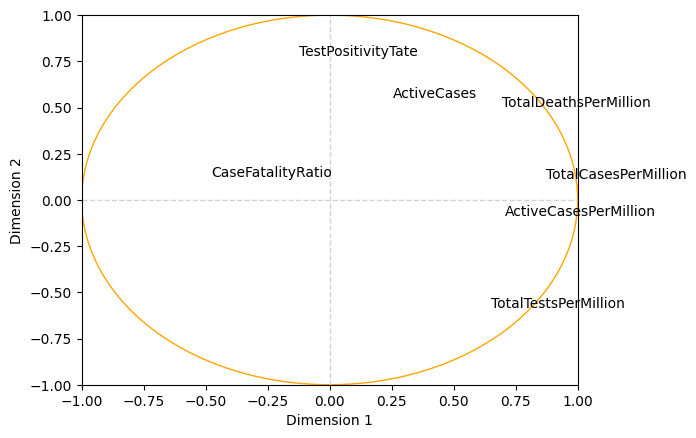

In [319]:
fig, ax = plt.subplots()
ax.set_ylim(-1,1)
ax.set_xlim(-1,1)
ax.axvline(x = 0, color = 'lightgray', linestyle = 'dashed', linewidth = 1)
ax.axhline(y = 0, color = 'lightgray', linestyle = 'dashed', linewidth = 1)
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
for j in range(p): 
    ax.text(coordvar['Correlation 1'][j],coordvar['Correlation 2'][j],coordvar['Variable'][j])
plt.gca().add_artist(plt.Circle((0,0),1,color='orange',fill=False))
plt.show()

# Le premier axe semble avoir un effet taille et c'est le premier axe qui concentre la plus part d'info. 
# Une lecture pertinente peut être : À droite les pays ayant des scores éléves  et à gauche le contraire. 
# L'axe Y, je la lirais comme Beaucoup de morts en haut et peu de morts en bas. 
# Les pays proches du 0 sont écrasés à mon avis. 


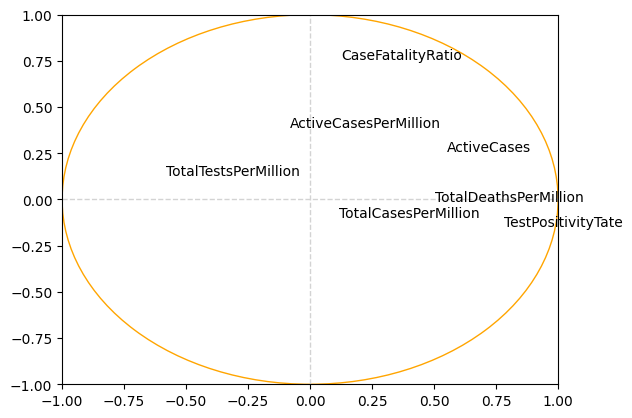

In [320]:
fig, ax = plt.subplots()
ax.set_ylim(-1,1)
ax.set_xlim(-1,1)
ax.axvline(x = 0, color = 'lightgray', linestyle = 'dashed', linewidth = 1)
ax.axhline(y = 0, color = 'lightgray', linestyle = 'dashed', linewidth = 1)
for j in range(p): 
    ax.text(coordvar['Correlation 2'][j],coordvar['Correlation 3'][j],coordvar['Variable'][j])
plt.gca().add_artist(plt.Circle((0,0),1,color='orange',fill=False))
plt.show()

# X comme le fait d'avoir beaucoup de morts et Y comme le fait d'avoir une actualité 
# forte en termes de cas. 

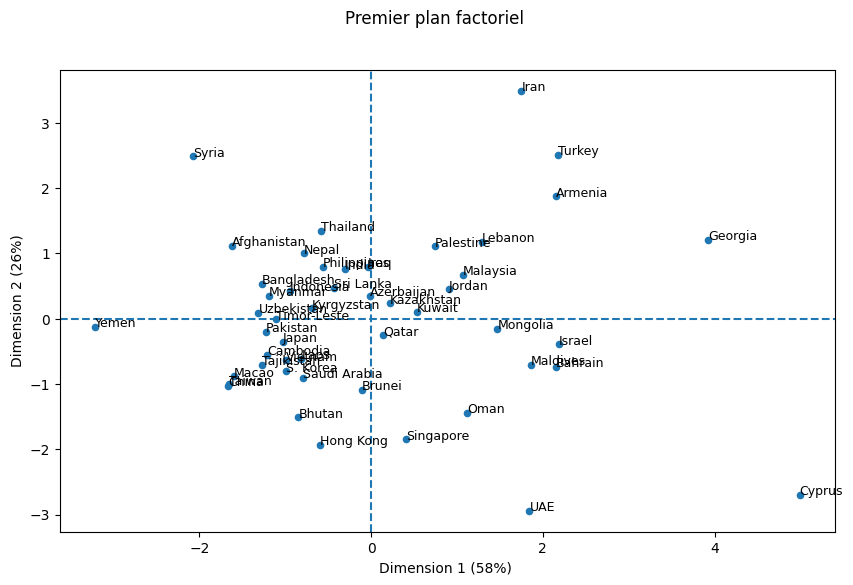

In [321]:
# Graphique ACP annoté des Pays. Dimensions 1 et 2.
fig, ax = plt.subplots()
fig.set_figheight(6)
fig.set_figwidth(10)
dim_pca_df_aug.plot.scatter("Dim 1", "Dim 2", ax = ax ) 
for i in dim_pca_df_aug.iterrows():
    ax.annotate(i[1]["Country"], (i[1]['Dim 1'], i[1]['Dim 2']), fontsize = 9)
plt.xlabel("Dimension 1 (58%) ") 
plt.ylabel("Dimension 2 (26%)")
plt.axhline(y =0, linestyle = 'dashed')
plt.axvline(x=0, linestyle ='dashed')

plt.suptitle("Premier plan factoriel")
plt.show()

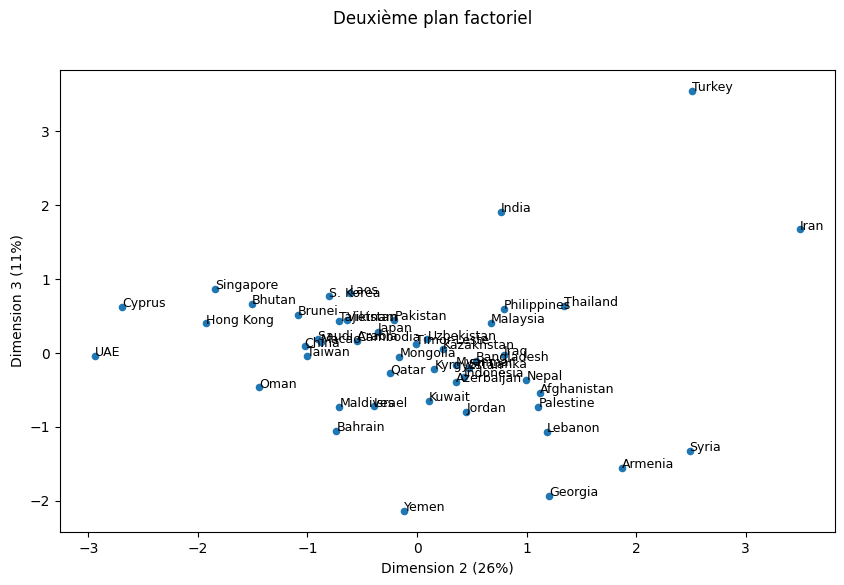

In [322]:
# Graphique ACP annoté des Pays. Dimensions 2 et 3.
fig, ax = plt.subplots()
fig.set_figheight(6)
fig.set_figwidth(10)
dim_pca_df_aug.plot.scatter("Dim 2", "Dim 3", ax = ax) 
for i in dim_pca_df_aug.iterrows():
    ax.annotate(i[1]["Country"], (i[1]['Dim 2'], i[1]['Dim 3']), fontsize = 9)
plt.xlabel("Dimension 2 (26%)") 
plt.ylabel("Dimension 3 (11%)")
plt.suptitle("Deuxième plan factoriel ")
plt.show()

## 4.2.2 Clustering - KMeans over Augmented DF

In [323]:
# Données de la PCA à utiliser dans Kmeans.
dim_pca_df_aug_km = dim_pca_df_aug.iloc[:,:-1]

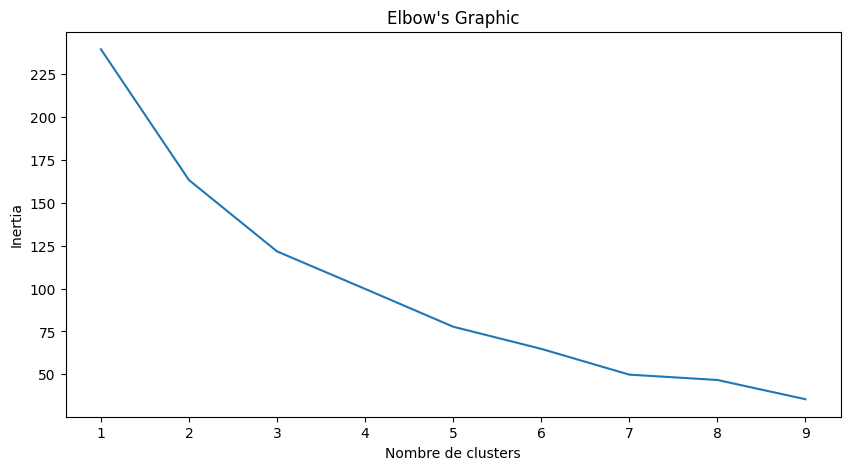

In [324]:
# Implementation de la methode du coude pour la selection optimale de K. 
elbow_scores = []
k = range(1, 10,1)

for i in k: 
    km = clu.KMeans(n_clusters= i)
    km.fit(dim_pca_df_aug_km)
    elbow_scores.append(km.inertia_)

plt.figure(figsize=(10,5))
plt.plot(k, elbow_scores)
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertia")
plt.title("Elbow's Graphic")
plt.show()
   

In [325]:
# Focus sur le k optimal. 
km = clu.KMeans(n_clusters= 3)
km.fit(dim_pca_df_aug_km)
group = km.predict(dim_pca_df_aug_km)
centers = km.cluster_centers_

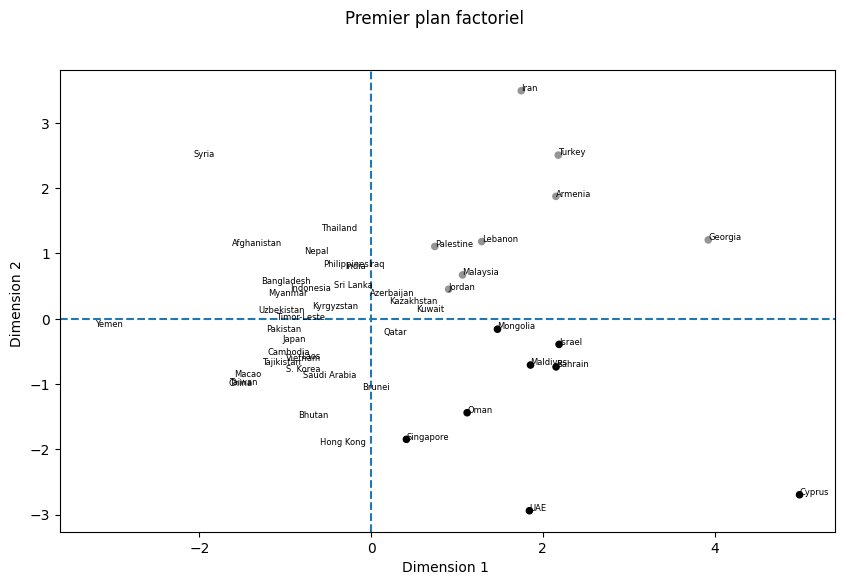

In [326]:
# Graphique ACP annoté des Pays. Dimensions 1 et 2. Clustering Inclus.
fig, ax = plt.subplots()
dim_pca_df_aug_km.plot.scatter("Dim 1", "Dim 2", ax = ax, color = group ) 
fig.set_figheight(6)
fig.set_figwidth(10)
for i in dim_pca_df_aug.iterrows():
    ax.annotate(i[1]["Country"], (i[1]['Dim 1'], i[1]['Dim 2']), fontsize = 6)
plt.xlabel("Dimension 1 ") 
plt.ylabel("Dimension 2 ")
plt.axhline(y =0, linestyle = 'dashed')
plt.axvline(x=0, linestyle ='dashed')

plt.suptitle("Premier plan factoriel")
plt.show()

In [327]:
# Graphique 3D de l'ACP.  Clustering Inclus. 
fig = px.scatter_3d(dim_pca_df_aug, x='Dim 1', y='Dim 2', z='Dim 3', text = 'Country', color = group)
fig.show()

In [328]:
# Silhouette Score pour la qualité du clustering 
s_score = met.silhouette_score(dim_pca_df_aug_km , group)
print(f"Le score de silhouette pour la qualité du clustering est : {s_score}")


Le score de silhouette pour la qualité du clustering est : 0.40440029364250024


In [329]:
dim_pca_df_aug['Group'] = np.transpose(group)
countryCluster = dim_pca_df_aug.drop(columns=['Dim 1', 'Dim 2', 'Dim 3'])

In [330]:
for i in range(3): 
    display(countryCluster[countryCluster['Group']== i ])
    print('----------------')
    

,Country,Group
0,Yemen,0
1,Vietnam,0
2,Uzbekistan,0
5,Timor-Leste,0
6,Thailand,0
7,Tajikistan,0
8,Taiwan,0
9,Syria,0
10,Sri Lanka,0
12,Saudi Arabia,0


----------------


,Country,Group
4,Turkey,1
16,Palestine,1
23,Malaysia,1
25,Lebanon,1
30,Jordan,1
34,Iran,1
38,Georgia,1
47,Armenia,1


----------------


,Country,Group
3,UAE,2
11,Singapore,2
18,Oman,2
21,Mongolia,2
22,Maldives,2
32,Israel,2
39,Cyprus,2
45,Bahrain,2


----------------


## 4.2.3 Clustering - GMM over DF Augmented

In [331]:
nb_components_base = list(range(2,11,1))
silhouettes_scores_base = []

In [332]:
for n in nb_components_base: 
    gmm = mix.GaussianMixture(n_components= n, random_state= 42)
    gmm.fit(dim_pca_df_aug_km)
    group = gmm.predict(dim_pca_df_aug_km)
    s_score = met.silhouette_score(dim_pca_df_aug_km , group)
    silhouettes_scores_base.append(s_score)
    

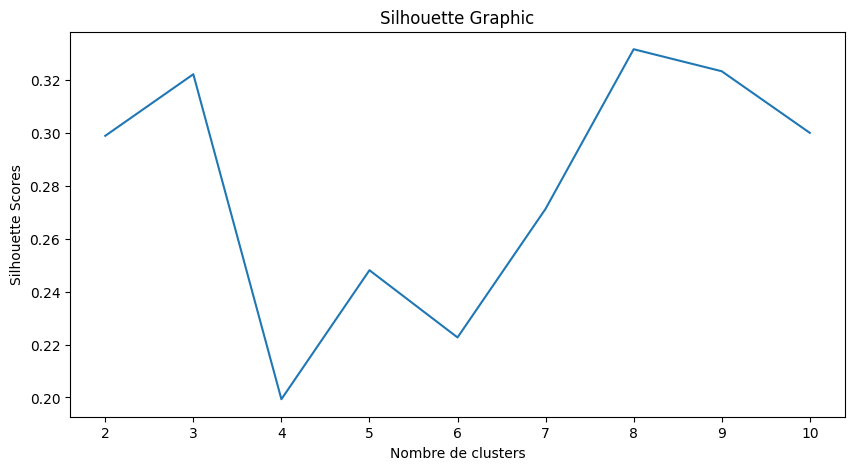

In [333]:
plt.figure(figsize=(10,5))
plt.plot(nb_components_base, silhouettes_scores_base)
plt.xlabel("Nombre de clusters")
plt.ylabel("Silhouette Scores")
plt.title("Silhouette Graphic")
plt.show()

In [334]:
gmm = mix.GaussianMixture(n_components= 3, random_state= 42)
gmm.fit(dim_pca_df_aug_km)
group = gmm.predict(dim_pca_df_aug_km)
s_score = met.silhouette_score(dim_pca_df_aug_km , group)
silhouettes_scores_base.append(s_score)    

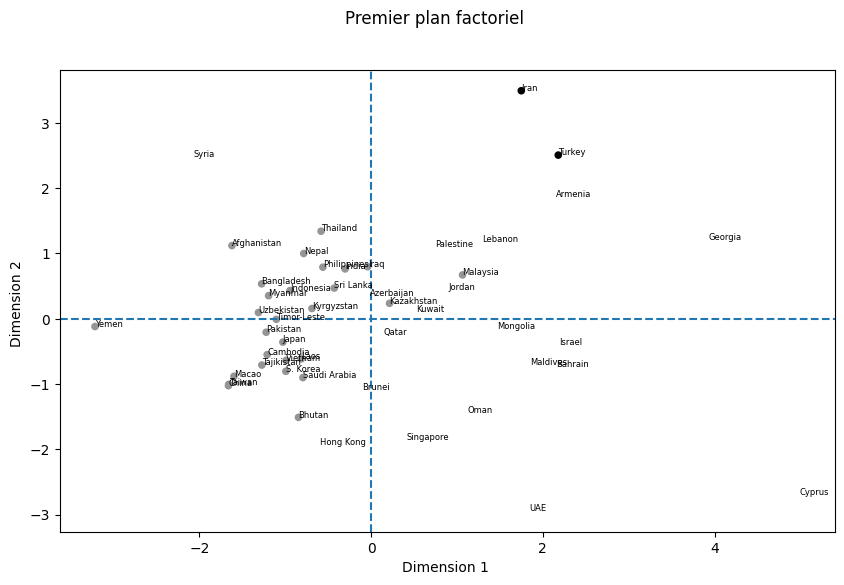

In [335]:
# Graphique ACP annoté des Pays. Dimensions 1 et 2. Clustering Inclus.
fig, ax = plt.subplots()
dim_pca_df_aug_km.plot.scatter("Dim 1", "Dim 2", ax = ax, color = group ) 
fig.set_figheight(6)
fig.set_figwidth(10)
for i in dim_pca_df_aug.iterrows():
    ax.annotate(i[1]["Country"], (i[1]['Dim 1'], i[1]['Dim 2']), fontsize = 6)
plt.xlabel("Dimension 1 ") 
plt.ylabel("Dimension 2 ")
plt.axhline(y =0, linestyle = 'dashed')
plt.axvline(x=0, linestyle ='dashed')

plt.suptitle("Premier plan factoriel")
plt.show()

In [336]:
# Graphique 3D de l'ACP.  Clustering Inclus. 
fig = px.scatter_3d(dim_pca_df_aug, x='Dim 1', y='Dim 2', z='Dim 3', text = 'Country', color = group)
fig.show()

Note : When our dataset has more variables, it introduces more variance. Therefore\
our clustering is underperforming comparing to our base dataset. Our showed results\
are based on the first dataframe. 

# 5. Follow Ups

## 5.1. Clustering on Base DF - HDBSCAN

In [337]:
hdbscan = clu.HDBSCAN(min_cluster_size= 4, min_samples= 4)
group = hdbscan.fit_predict(dim_pca_df_base_km)
s_score = met.silhouette_score(dim_pca_df_base_km,group)

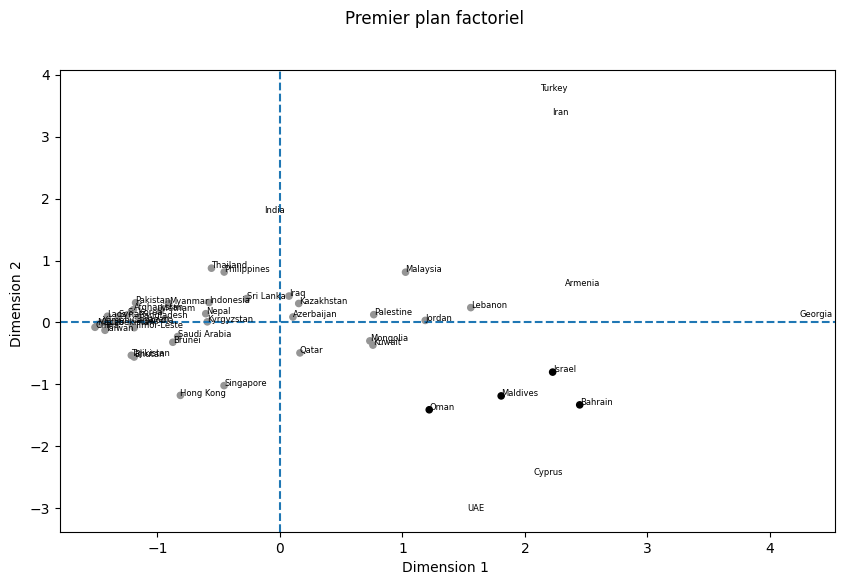

In [338]:
# Graphique ACP annoté des Pays. Dimensions 1 et 2. Clustering Inclus.
fig, ax = plt.subplots()
dim_pca_df_base_km.plot.scatter("Dim 1", "Dim 2", ax = ax, color = group ) 
fig.set_figheight(6)
fig.set_figwidth(10)
for i in dim_pca_df_base.iterrows():
    ax.annotate(i[1]["Country"], (i[1]['Dim 1'], i[1]['Dim 2']), fontsize = 6)
plt.xlabel("Dimension 1 ") 
plt.ylabel("Dimension 2 ")
plt.axhline(y =0, linestyle = 'dashed')
plt.axvline(x=0, linestyle ='dashed')

plt.suptitle("Premier plan factoriel")
plt.show()

In [339]:
# Graphique 3D de l'ACP.  Clustering Inclus. 
fig = px.scatter_3d(dim_pca_df_base, x='Dim 1', y='Dim 2', z='Dim 3', text = 'Country', color = group)
fig.show()

## 5.2. Treatment on Base DF Without Outliers

In [340]:
df_hdbscan_clean_index = df_base_clean_index.copy()
df_hdbscan_clean_index.insert(1, "Group", group)
df_hdbscan_clean_index.head()

,ActiveCases,Group,TotalCasesPerMillion,TotalDeathsPerMillion,TotalTestsPerMillion
Country,,,,,
Yemen,1670,0,306,58.0,8651.0
Vietnam,36908,0,8529,209.0,431850.0
Uzbekistan,3153,0,5241,37.0,40425.0
UAE,4481,-1,73477,211.0,8687776.0
Turkey,484896,-1,87077,774.0,1050928.0


In [341]:
df_hdbscan_outliers_free = df_hdbscan_clean_index[df_hdbscan_clean_index['Group'] != -1]

In [342]:
df_hdbscan_outliers_free_clean = df_hdbscan_outliers_free.drop(columns="Group")
df_outliers_free_column = df_hdbscan_outliers_free_clean.columns
df_outliers_free_index = df_hdbscan_outliers_free_clean.index

In [343]:
scaler = pre.StandardScaler()
df_outliers_free_scaled = pd.DataFrame(scaler.fit_transform(df_hdbscan_outliers_free_clean),
                                   columns=df_outliers_free_column,
                                   index = df_outliers_free_index)

In [344]:
# Missing Values imputation
imputer = KNNImputer(n_neighbors= 4, weights='distance')
df_outliers_free_imputed = pd.DataFrame(imputer.fit_transform(df_outliers_free_scaled),
                                    columns = df_outliers_free_column,
                                    index = df_outliers_free_index)

In [345]:
pca = PCA() 
pca.fit(df_outliers_free_imputed)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [346]:
n = df_base_clean_imputed.shape[0]
p = df_base_clean_imputed.shape[1]-1
Dimension = ['Dim' +' '+str(x+1) for x in range(len(pca.explained_variance_+1))]
eigval = ((n-1)/n)*pca.explained_variance_

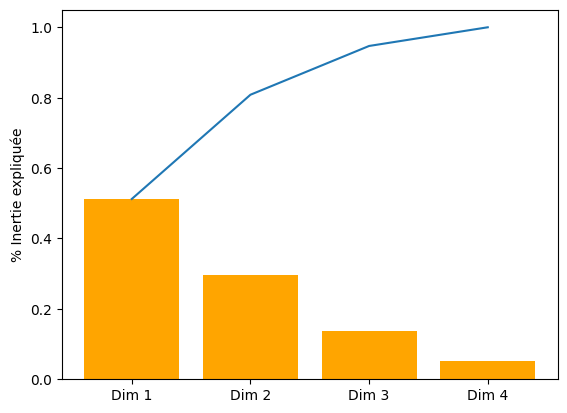

In [347]:
# Variance Expliquée par chaque dimension. 
plt.Figure(figsize=(10,5))
plt.plot(Dimension , np.cumsum(pca.explained_variance_ratio_))
plt.bar(Dimension , pca.explained_variance_ratio_, color = 'Orange')
plt.ylabel('% Inertie expliquée')
plt.show()


In [348]:
# Representation de la PCA. 
pca_df_outliers_free = pca.transform(df_outliers_free_imputed)
dim_pca_df_outliers_free = pd.DataFrame({'Dim 1':pca_df_outliers_free[:,0], 
                           'Dim 2':pca_df_outliers_free[:,1], 
                           'Dim 3':pca_df_outliers_free[:,2],
                           'Country': df_hdbscan_outliers_free.index})
dim_pca_df_outliers_free.head()

,Dim 1,Dim 2,Dim 3,Country
0,-1.466710,-0.496213,-0.345654,Yemen
1,-0.821515,0.528710,0.326712,Vietnam
2,-1.415499,-0.486189,-0.289177,Uzbekistan
3,-1.151611,-0.562959,-0.397213,Timor-Leste
4,-0.466183,2.860259,1.382373,Thailand


In [349]:
# Cercle de correlation. 
n = df_outliers_free_imputed.shape[0]
p = df_outliers_free_imputed.shape[1]
eigval = ((n-1)/n)* pca.explained_variance_ 
sqrt_eigval = np.sqrt(eigval) 
corvar = np.zeros((p,p)) 

for i in range(p):
    corvar[:,i] = pca.components_[i,:] * sqrt_eigval[i]
coordvar = pd.DataFrame({'Variable': df_outliers_free_imputed.columns, 'Correlation 1': corvar[:,0], 'Correlation 2': corvar[:,1],'Correlation 3': corvar[:,3]})
coordvar

,Variable,Correlation 1,Correlation 2,Correlation 3
0,ActiveCases,0.081980,0.916057,0.042207
1,TotalCasesPerMillion,0.932237,-0.023802,0.339582
2,TotalDeathsPerMillion,0.845147,0.321755,-0.280967
3,TotalTestsPerMillion,0.669617,-0.485113,-0.123313


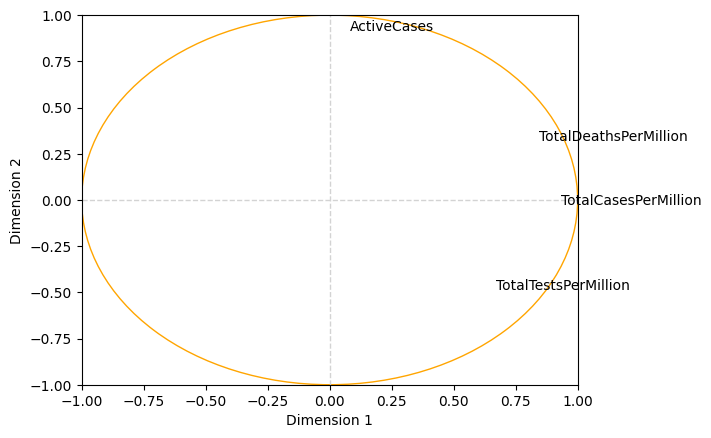

In [350]:
fig, ax = plt.subplots()
ax.set_ylim(-1,1)
ax.set_xlim(-1,1)
ax.axvline(x = 0, color = 'lightgray', linestyle = 'dashed', linewidth = 1)
ax.axhline(y = 0, color = 'lightgray', linestyle = 'dashed', linewidth = 1)
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
for j in range(p): 
    ax.text(coordvar['Correlation 1'][j],coordvar['Correlation 2'][j],coordvar['Variable'][j])
plt.gca().add_artist(plt.Circle((0,0),1,color='orange',fill=False))
plt.show()

# Le premier axe semble avoir un effet taille et c'est le premier axe qui concentre la plus part d'info. 
# Une lecture pertinente peut être : À droite les pays ayant des scores éléves  et à gauche le contraire. 
# L'axe Y, je la lirais comme Beaucoup de morts en haut et peu de morts en bas. 
# Les pays proches du 0 sont écrasés à mon avis. 


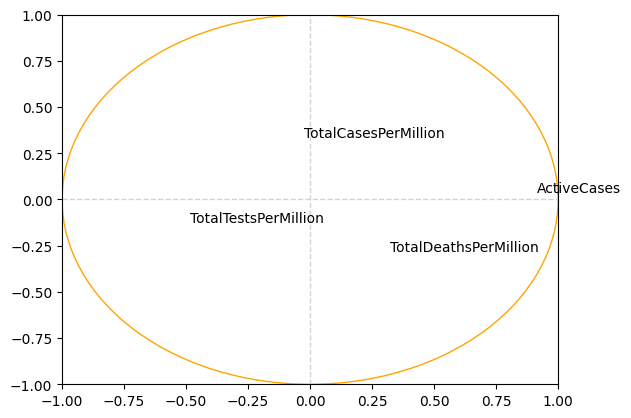

In [351]:
fig, ax = plt.subplots()
ax.set_ylim(-1,1)
ax.set_xlim(-1,1)
ax.axvline(x = 0, color = 'lightgray', linestyle = 'dashed', linewidth = 1)
ax.axhline(y = 0, color = 'lightgray', linestyle = 'dashed', linewidth = 1)
for j in range(p): 
    ax.text(coordvar['Correlation 2'][j],coordvar['Correlation 3'][j],coordvar['Variable'][j])
plt.gca().add_artist(plt.Circle((0,0),1,color='orange',fill=False))
plt.show()

# X comme le fait d'avoir beaucoup de morts et Y comme le fait d'avoir une actualité 
# forte en termes de cas. 

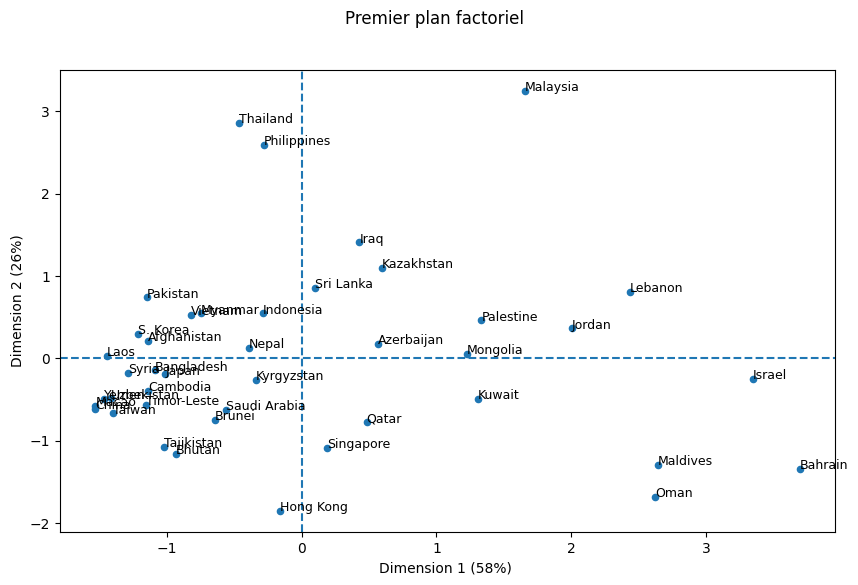

In [352]:
# Graphique ACP annoté des Pays. Dimensions 1 et 2.
fig, ax = plt.subplots()
fig.set_figheight(6)
fig.set_figwidth(10)
dim_pca_df_outliers_free.plot.scatter("Dim 1", "Dim 2", ax = ax ) 
for i in dim_pca_df_outliers_free.iterrows():
    ax.annotate(i[1]["Country"], (i[1]['Dim 1'], i[1]['Dim 2']), fontsize = 9)
plt.xlabel("Dimension 1 (58%) ") 
plt.ylabel("Dimension 2 (26%)")
plt.axhline(y =0, linestyle = 'dashed')
plt.axvline(x=0, linestyle ='dashed')

plt.suptitle("Premier plan factoriel")
plt.show()

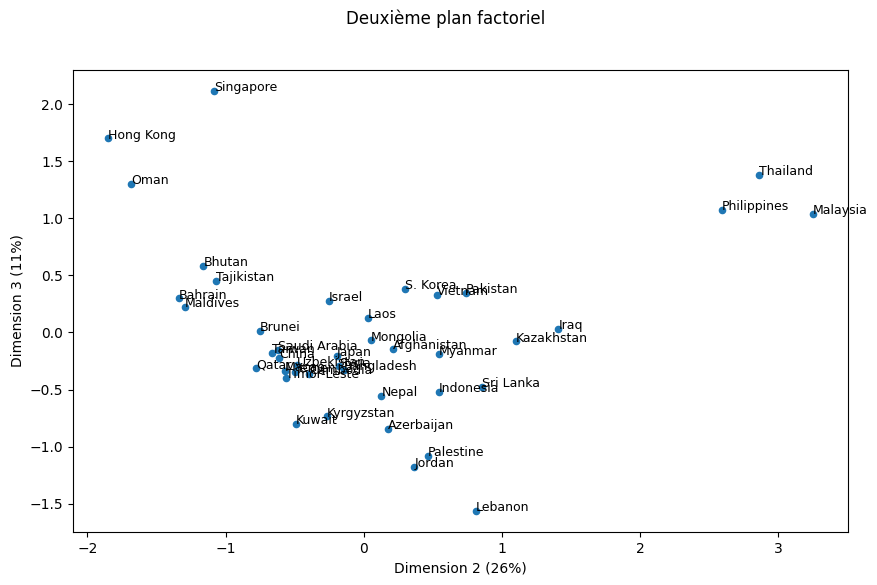

In [353]:
# Graphique ACP annoté des Pays. Dimensions 2 et 3.
fig, ax = plt.subplots()
fig.set_figheight(6)
fig.set_figwidth(10)
dim_pca_df_outliers_free.plot.scatter("Dim 2", "Dim 3", ax = ax) 
for i in dim_pca_df_outliers_free.iterrows():
    ax.annotate(i[1]["Country"], (i[1]['Dim 2'], i[1]['Dim 3']), fontsize = 9)
plt.xlabel("Dimension 2 (26%)") 
plt.ylabel("Dimension 3 (11%)")
plt.suptitle("Deuxième plan factoriel ")
plt.show()

In [354]:
# Graphique 3D de l'ACP.  Clustering Inclus. 
fig = px.scatter_3d(dim_pca_df_outliers_free, x='Dim 1', y='Dim 2', z='Dim 3', text = 'Country')
fig.show()

## 5.3. Clustering - KMeans over Base DF without outliers

In [355]:
# Données de la PCA à utiliser dans Kmeans.
dim_pca_df_outliers_km = dim_pca_df_outliers_free.iloc[:,:-1]

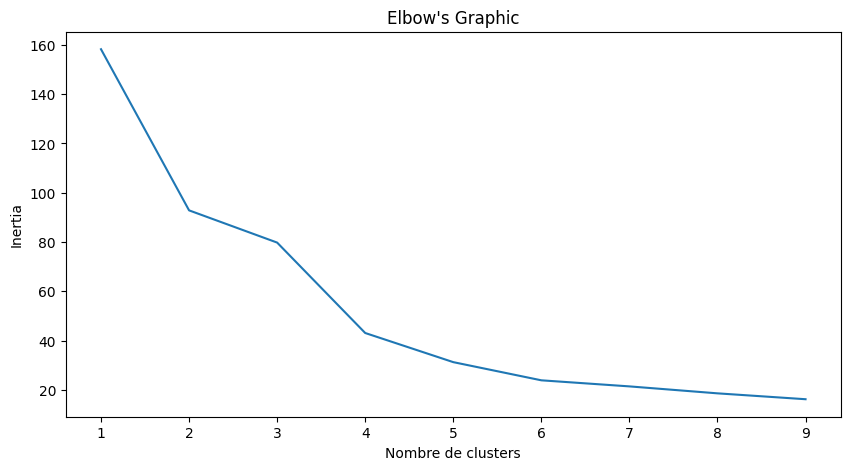

In [356]:
# Implementation de la methode du coude pour la selection optimale de K. 
elbow_scores = []
k = range(1, 10,1)

for i in k: 
    km = clu.KMeans(n_clusters= i)
    km.fit(dim_pca_df_outliers_km)
    elbow_scores.append(km.inertia_)

plt.figure(figsize=(10,5))
plt.plot(k, elbow_scores)
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertia")
plt.title("Elbow's Graphic")
plt.show()
   

In [363]:
# Focus sur le k optimal. 
km = clu.KMeans(n_clusters= 4)
km.fit(dim_pca_df_outliers_km)
group = km.predict(dim_pca_df_outliers_km)
centers = km.cluster_centers_

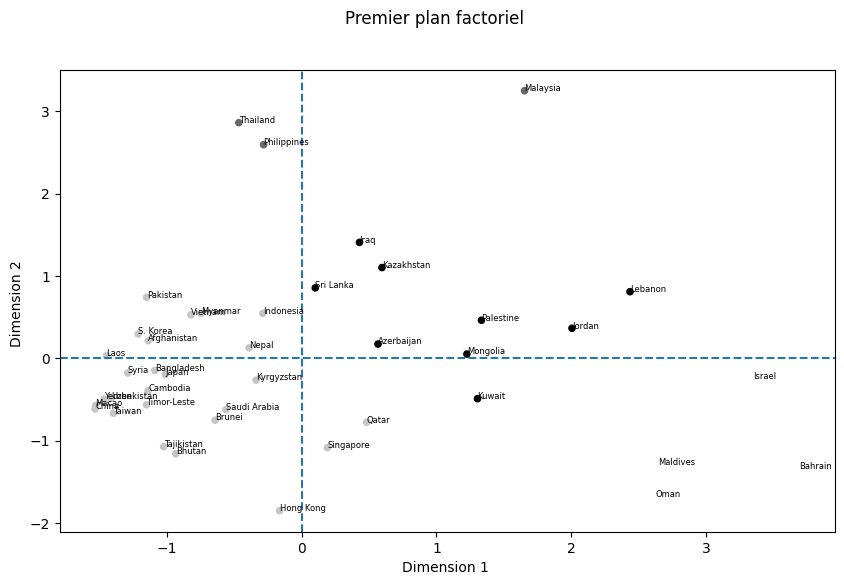

In [364]:
# Graphique ACP annoté des Pays. Dimensions 1 et 2. Clustering Inclus.
fig, ax = plt.subplots()
dim_pca_df_outliers_free.plot.scatter("Dim 1", "Dim 2", ax = ax, color = group ) 
fig.set_figheight(6)
fig.set_figwidth(10)
for i in dim_pca_df_outliers_free.iterrows():
    ax.annotate(i[1]["Country"], (i[1]['Dim 1'], i[1]['Dim 2']), fontsize = 6)
plt.xlabel("Dimension 1 ") 
plt.ylabel("Dimension 2 ")
plt.axhline(y =0, linestyle = 'dashed')
plt.axvline(x=0, linestyle ='dashed')

plt.suptitle("Premier plan factoriel")
plt.show()

In [365]:
# Graphique 3D de l'ACP.  Clustering Inclus. 
fig = px.scatter_3d(dim_pca_df_outliers_free, x='Dim 1', y='Dim 2', z='Dim 3', text = 'Country', color = group)
fig.show()

In [366]:
# Silhouette Score pour la qualité du clustering 
s_score = met.silhouette_score(dim_pca_df_outliers_km , group)
print(f"Le score de silhouette pour la qualité du clustering est : {s_score}")


Le score de silhouette pour la qualité du clustering est : 0.4755315938870703


In [367]:
dim_pca_df_outliers_free['Group'] = np.transpose(group)
countryCluster = dim_pca_df_outliers_free.drop(columns=['Dim 1', 'Dim 2', 'Dim 3'])

In [368]:
for i in range(2): 
    display(countryCluster[countryCluster['Group']== i ])
    print('----------------')

,Country,Group
16,Oman,0
20,Maldives,0
30,Israel,0
39,Bahrain,0


----------------


,Country,Group
0,Yemen,1
1,Vietnam,1
2,Uzbekistan,1
3,Timor-Leste,1
5,Tajikistan,1
6,Taiwan,1
7,Syria,1
9,Singapore,1
10,Saudi Arabia,1
11,S. Korea,1


----------------
